## Лабораторная работа №1: Визуализация данных

Выполнил студент группы 6401-010302D Смирнов Андрей Александрович


In [33]:
pip install ipywidgets


In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider
import seaborn as sns
import plotly as pl
import scipy.stats as stats, gaussian_kde
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

ModuleNotFoundError: No module named 'gaussian_kde'

### 1. Считать в `pandas.DataFrame` любой источник данных: CSV, JSON, Excel-файл, HTML-таблицу и т.п.
Также можно сконвертировать в DataFrame любой из встроенных датасетов `sklearn`: (см. [инструкцию](https://stackoverflow.com/questions/38105539/how-to-convert-a-scikit-learn-dataset-to-a-pandas-dataset)).  
   > Главное условие к датасету, который вы загружаете &ndash; там должны быть как минимум пара числовых колонок и как минимум одна категориальная с небольшим числом категорий.

In [35]:
df = pd.read_csv("/content/student-mat.csv", delimiter=';')
pd.set_option('display.max_columns', None)

df

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,3,yes,no,yes,no,yes,yes,yes,no,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,yes,yes,yes,yes,yes,yes,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,yes,no,yes,yes,no,no,4,3,2,1,2,5,4,6,10,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,MS,M,20,U,LE3,A,2,2,services,services,course,other,1,2,2,no,yes,yes,no,yes,yes,no,no,5,5,4,4,5,4,11,9,9,9
391,MS,M,17,U,LE3,T,3,1,services,services,course,mother,2,1,0,no,no,no,no,no,yes,yes,no,2,4,5,3,4,2,3,14,16,16
392,MS,M,21,R,GT3,T,1,1,other,other,course,other,1,1,3,no,no,no,no,no,yes,no,no,5,5,3,3,3,3,3,10,8,7
393,MS,M,18,R,LE3,T,3,2,services,other,course,mother,3,1,0,no,no,no,no,no,yes,yes,no,4,4,1,3,4,5,0,11,12,10



### 2. Привести описание датасета.  



Датасет содержит различные данные об учениках двух школ в Португалии.


| Признак | Описание | Тип / Единицы измерения
   | --- | --- | --- |
school | Школа ученика | Категориальный, бинарный: 'GP' / 'MS'
sex | Пол ученика |Категориальный, бинарный: 'F' / 'M'
age | Возраст ученика |Числовой, годы (15–22)
address |Тип места проживания | Категориальный, бинарный: 'U' (город) / 'R' (село)
famsize |Размер семьи |Категориальный, бинарный: 'LE3' (≤3) / 'GT3' (>3)
Pstatus |Статус совместного проживания родителей |Категориальный, бинарный: 'T' (вместе) / 'A' (раздельно)
Medu |Уровень образования матери |Порядковый, шкала 0–4 (0: нет, 1: начальное, 2: 5–9 кл., 3: среднее, 4: высшее)
Fedu |Уровень образования отца | Порядковый, шкала 0–4 (аналогично Medu)
Mjob |Работа матери |Категориальный, номинальный: 'teacher', 'health', 'services', 'at_home', 'other'
Fjob |Работа отца |Категориальный, номинальный (аналогично Mjob)
reason|Причина выбора школы |Категориальный, номинальный: 'home', 'reputation', 'course', 'other'
guardian | Опекун ученика | Категориальный, номинальный: 'mother', 'father', 'other'
traveltime| Время пути от дома до школы | Порядковый, шкала 1–4 (1: <15 мин, 2: 15–30 мин, 3: 30–60 мин, 4: >1 ч)
studytime | Еженедельное время на учёбу | Порядковый, шкала 1–4 (1: <2 ч, 2: 2–5 ч, 3: 5–10 ч, 4: >10 ч)
failures | Количество прошлых неудач (несданных предметов) | Числовой, дискретный: 1, 2, или 4 (если ≥3)
schoolsup | Дополнительная образовательная поддержка от школы | Бинарный: 'yes' / 'no'
famsup | Образовательная поддержка от семьи | Бинарный: 'yes' / 'no'
paid | Дополнительные платные занятия по предмету | Бинарный: 'yes' / 'no'
activities | Участие во внеклассных мероприятиях | Бинарный: 'yes' / 'no'
nursery | Посещение детского сада | Бинарный: 'yes' / 'no'
higher | Планирует ли получать высшее образование | Бинарный: 'yes' / 'no'
internet | Наличие интернета дома | Бинарный: 'yes' / 'no'
romantic | Наличие романтических отношений | Бинарный: 'yes' / 'no'
famrel | Качество семейных отношений | Порядковый, шкала 1–5 (1: очень плохо, 5: отлично)
freetime | Количество свободного времени после школы | Порядковый, шкала 1–5 (1: очень мало, 5: очень много)
goout | Частота встреч с друзьями | Порядковый, шкала 1–5 (1: очень редко, 5: очень часто)
Dalc | Потребление алкоголя в будние дни |Порядковый, шкала 1–5 (1: очень мало, 5: очень много)
Walc | Потребление алкоголя в выходные дни | Порядковый, шкала 1–5 (аналогично Dalc)
health | Текущее состояние здоровья | Порядковый, шкала 1–5 (1: очень плохое, 5: отличное)
absences | Количество пропусков школы | Числовой, счётчик (0–93)



### 3. `matplotlib`:  
   - Построить несколько графиков разного вида с использованием `matplotlib`.  
   - Построить несколько суб-графиков на одном графике используя `.subplot`.  
   - Построить интерактивный график со слайдером.
   
   > - Графики должны быть разных видов.  
   > - Хотя бы в одном графике необходимо подписать оси.  
   > - Во всех графиках необходимо указать название.
   > - Необязательно строить сложный и перегруженный информацией интерактивный график, достаточно одного-двух числовых признаков в разрезе другого признака, как минимум добавить слайдер (ползунок). Наличие других графических элементов управления (кнопки и т.п.) &ndash; опционально.

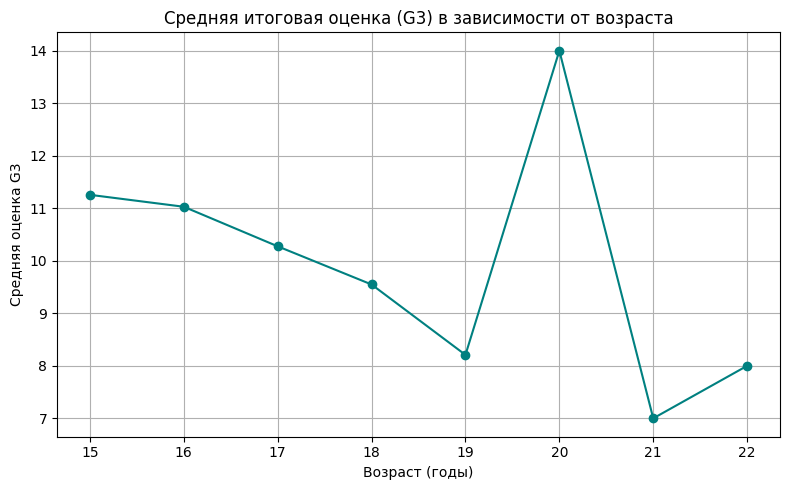

In [36]:
plt.figure(figsize=(8,5))
mean_grade_by_age = df.groupby('age')['G3'].mean()
plt.plot(mean_grade_by_age.index, mean_grade_by_age.values, marker='o', linestyle='-', color='teal')
plt.title('Средняя итоговая оценка (G3) в зависимости от возраста', fontsize=12)
plt.xlabel('Возраст (годы)')
plt.ylabel('Средняя оценка G3')
plt.grid(True)
plt.tight_layout()
plt.show()

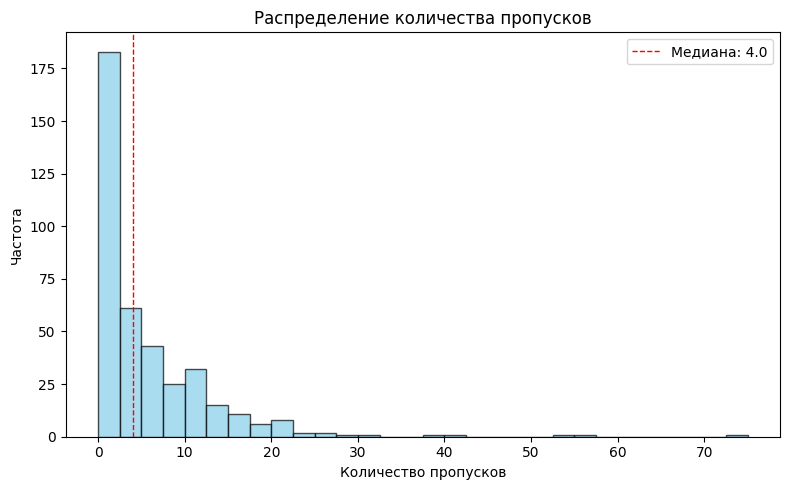

In [37]:
plt.figure(figsize=(8,5))
plt.hist(df['absences'], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Распределение количества пропусков', fontsize=12)
plt.xlabel('Количество пропусков')
plt.ylabel('Частота')
plt.axvline(df['absences'].median(), color='red', linestyle='dashed', linewidth=1, label=f'Медиана: {df["absences"].median()}')
plt.legend()
plt.tight_layout()
plt.show()

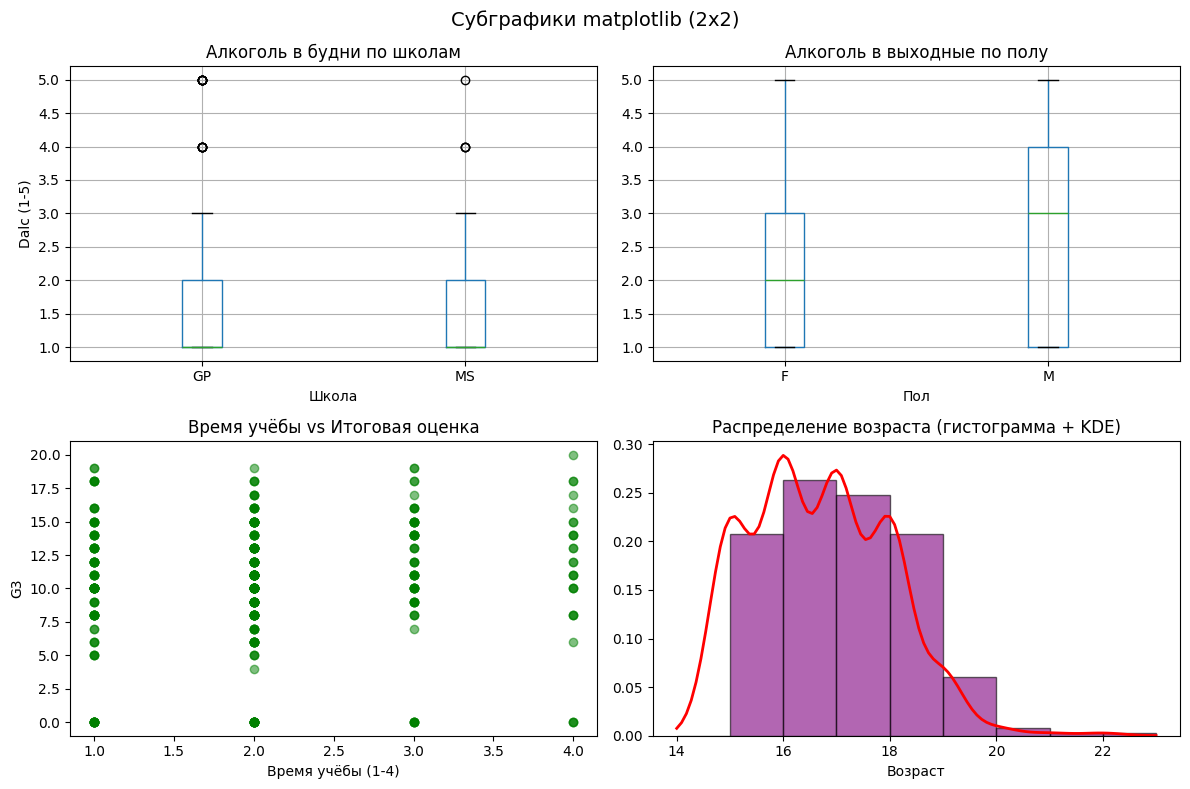

In [53]:
# 3.3 Subplot (2x2) – сравнение алкоголя в будни и выходные, а также времени учёбы
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# (1) Boxplot Dalc по школам
df.boxplot(column='Dalc', by='school', ax=axes[0,0])
axes[0,0].set_title('Алкоголь в будни по школам')
axes[0,0].set_xlabel('Школа')
axes[0,0].set_ylabel('Dalc (1-5)')

# (2) Violinplot Walc по полу (с помощью matplotlib можно, но проще через seaborn? но мы используем чистый matplotlib – сделаем boxplot)
df.boxplot(column='Walc', by='sex', ax=axes[0,1])
axes[0,1].set_title('Алкоголь в выходные по полу')
axes[0,1].set_xlabel('Пол')

# (3) Scatter: studytime vs G3
axes[1,0].scatter(df['studytime'], df['G3'], alpha=0.5, color='green')
axes[1,0].set_title('Время учёбы vs Итоговая оценка')
axes[1,0].set_xlabel('Время учёбы (1-4)')
axes[1,0].set_ylabel('G3')

# (4) Гистограмма возраста с наложением KDE (можно через plt.hist + density)
axes[1,1].hist(df['age'], bins=range(14,24), density=True, alpha=0.6, color='purple', edgecolor='black')


kde = gaussian_kde(df['age'])
x_range = np.linspace(14, 23, 100)
axes[1,1].plot(x_range, kde(x_range), 'r-', linewidth=2)
axes[1,1].set_title('Распределение возраста (гистограмма + KDE)')
axes[1,1].set_xlabel('Возраст')
plt.suptitle('Субграфики matplotlib (2x2)', fontsize=14)
plt.tight_layout()
plt.show()

In [54]:
%matplotlib inline

def update_plot(age):
    plt.figure(figsize=(9,6))
    filtered = df[df['age'] == age]

    if filtered.empty:
        plt.text(0.5, 0.5, 'Нет данных для этого возраста',
                 ha='center', va='center', transform=plt.gca().transAxes, fontsize=14)
    else:
        plt.scatter(filtered['studytime'], filtered['absences'], alpha=0.7, c='coral')

    plt.title(f'Пропуски vs Время учёбы (возраст = {age})')
    plt.xlabel('Время учёбы (1-4)')
    plt.ylabel('Количество пропусков')
    plt.xlim(0, 5)
    plt.ylim(0, df['absences'].max()+5)
    plt.grid(True, alpha=0.3)
    plt.show()

# Запуск слайдера
age_min, age_max = int(df['age'].min()), int(df['age'].max())
interact(update_plot, age=(age_min, age_max, 1))

interactive(children=(IntSlider(value=18, description='age', max=22, min=15), Output()), _dom_classes=('widget…

<function __main__.update_plot(age)>

### 4. `pandas`:  
   - Построить три разных вида графиков с использованием `pandas.DataFrame.plot` / `Series.plot`.  
   
   > - Среди графиков должен присутствовать один `boxplot` (обязательно надо использовать параметр `by` для исследования взаимосвязи числовой переменной и какой-либо другой).  
   > - Графики должны быть построены как через методы `DataFrame`, так и через методы `Series`. То есть оба варианта нужно продемонстрировать.  

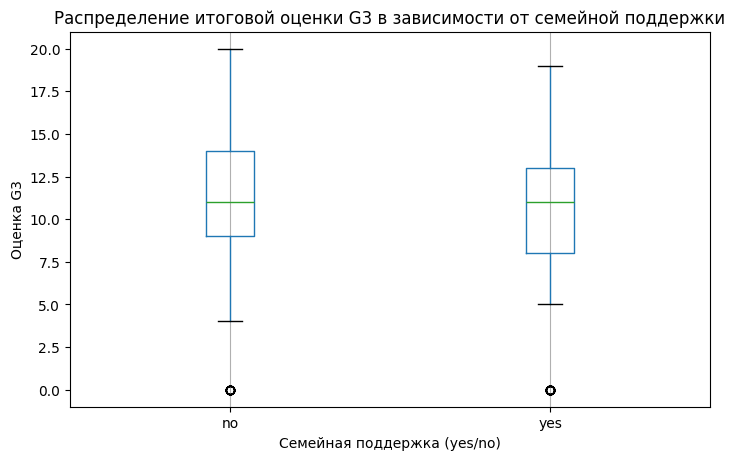

In [55]:
# Версия с DataFrame.plot()
df.boxplot(column='G3', by='famsup', figsize=(8,5))
plt.title('Распределение итоговой оценки G3 в зависимости от семейной поддержки')
plt.suptitle('')
plt.xlabel('Семейная поддержка (yes/no)')
plt.ylabel('Оценка G3')
plt.grid(axis='y')
plt.show()

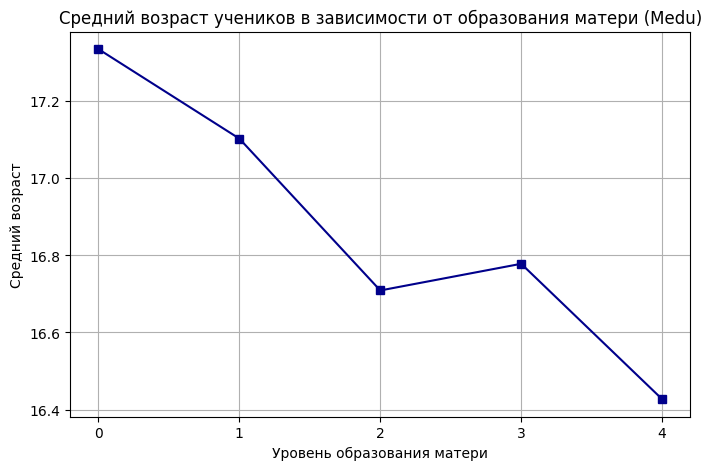

In [41]:
# Версия с Series.plot()
mean_age_by_Medu = df.groupby('Medu')['age'].mean()
mean_age_by_Medu.plot(kind='line', marker='s', color='darkblue', figsize=(8,5))
plt.title('Средний возраст учеников в зависимости от образования матери (Medu)')
plt.xlabel('Уровень образования матери')
plt.ylabel('Средний возраст')
plt.xticks(range(0,5))
plt.grid(True)
plt.show()

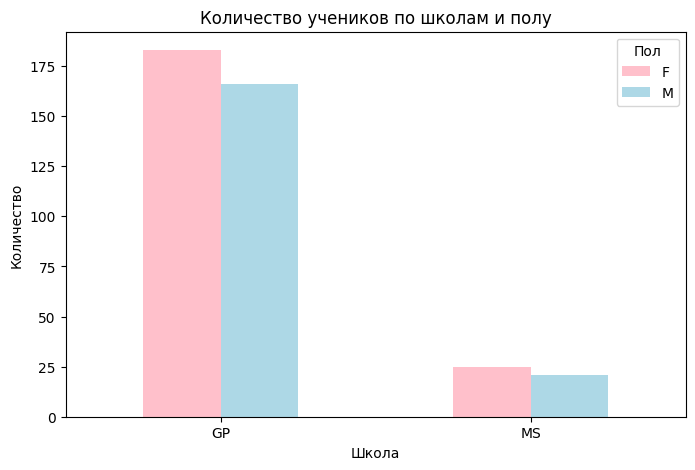

In [42]:
pd.crosstab(df['school'], df['sex']).plot(kind='bar', figsize=(8,5), color=['pink', 'lightblue'])
plt.title('Количество учеников по школам и полу')
plt.xlabel('Школа')
plt.ylabel('Количество')
plt.xticks(rotation=0)
plt.legend(title='Пол')
plt.show()

### 5. `seaborn`:  
   - Построить `.pairplot` на каком-либо наборе данных, проанализировать взаимосвязь набора числовых признаков.  
   - Построить `.jointplot`, проанализировать взаимосвязь двух конкретных числовых признаков.  
   - Построить `.boxplot` и/или `.violinplot` на каком-либо наборе данных, проанализировать числовой признак в разрезе категориального.  
   - Построить график `.heatmap` попарной корреляции всех числовых признаков.  
   
     > Категориальные признаки необходимо убрать из датафрейма перед построением.  

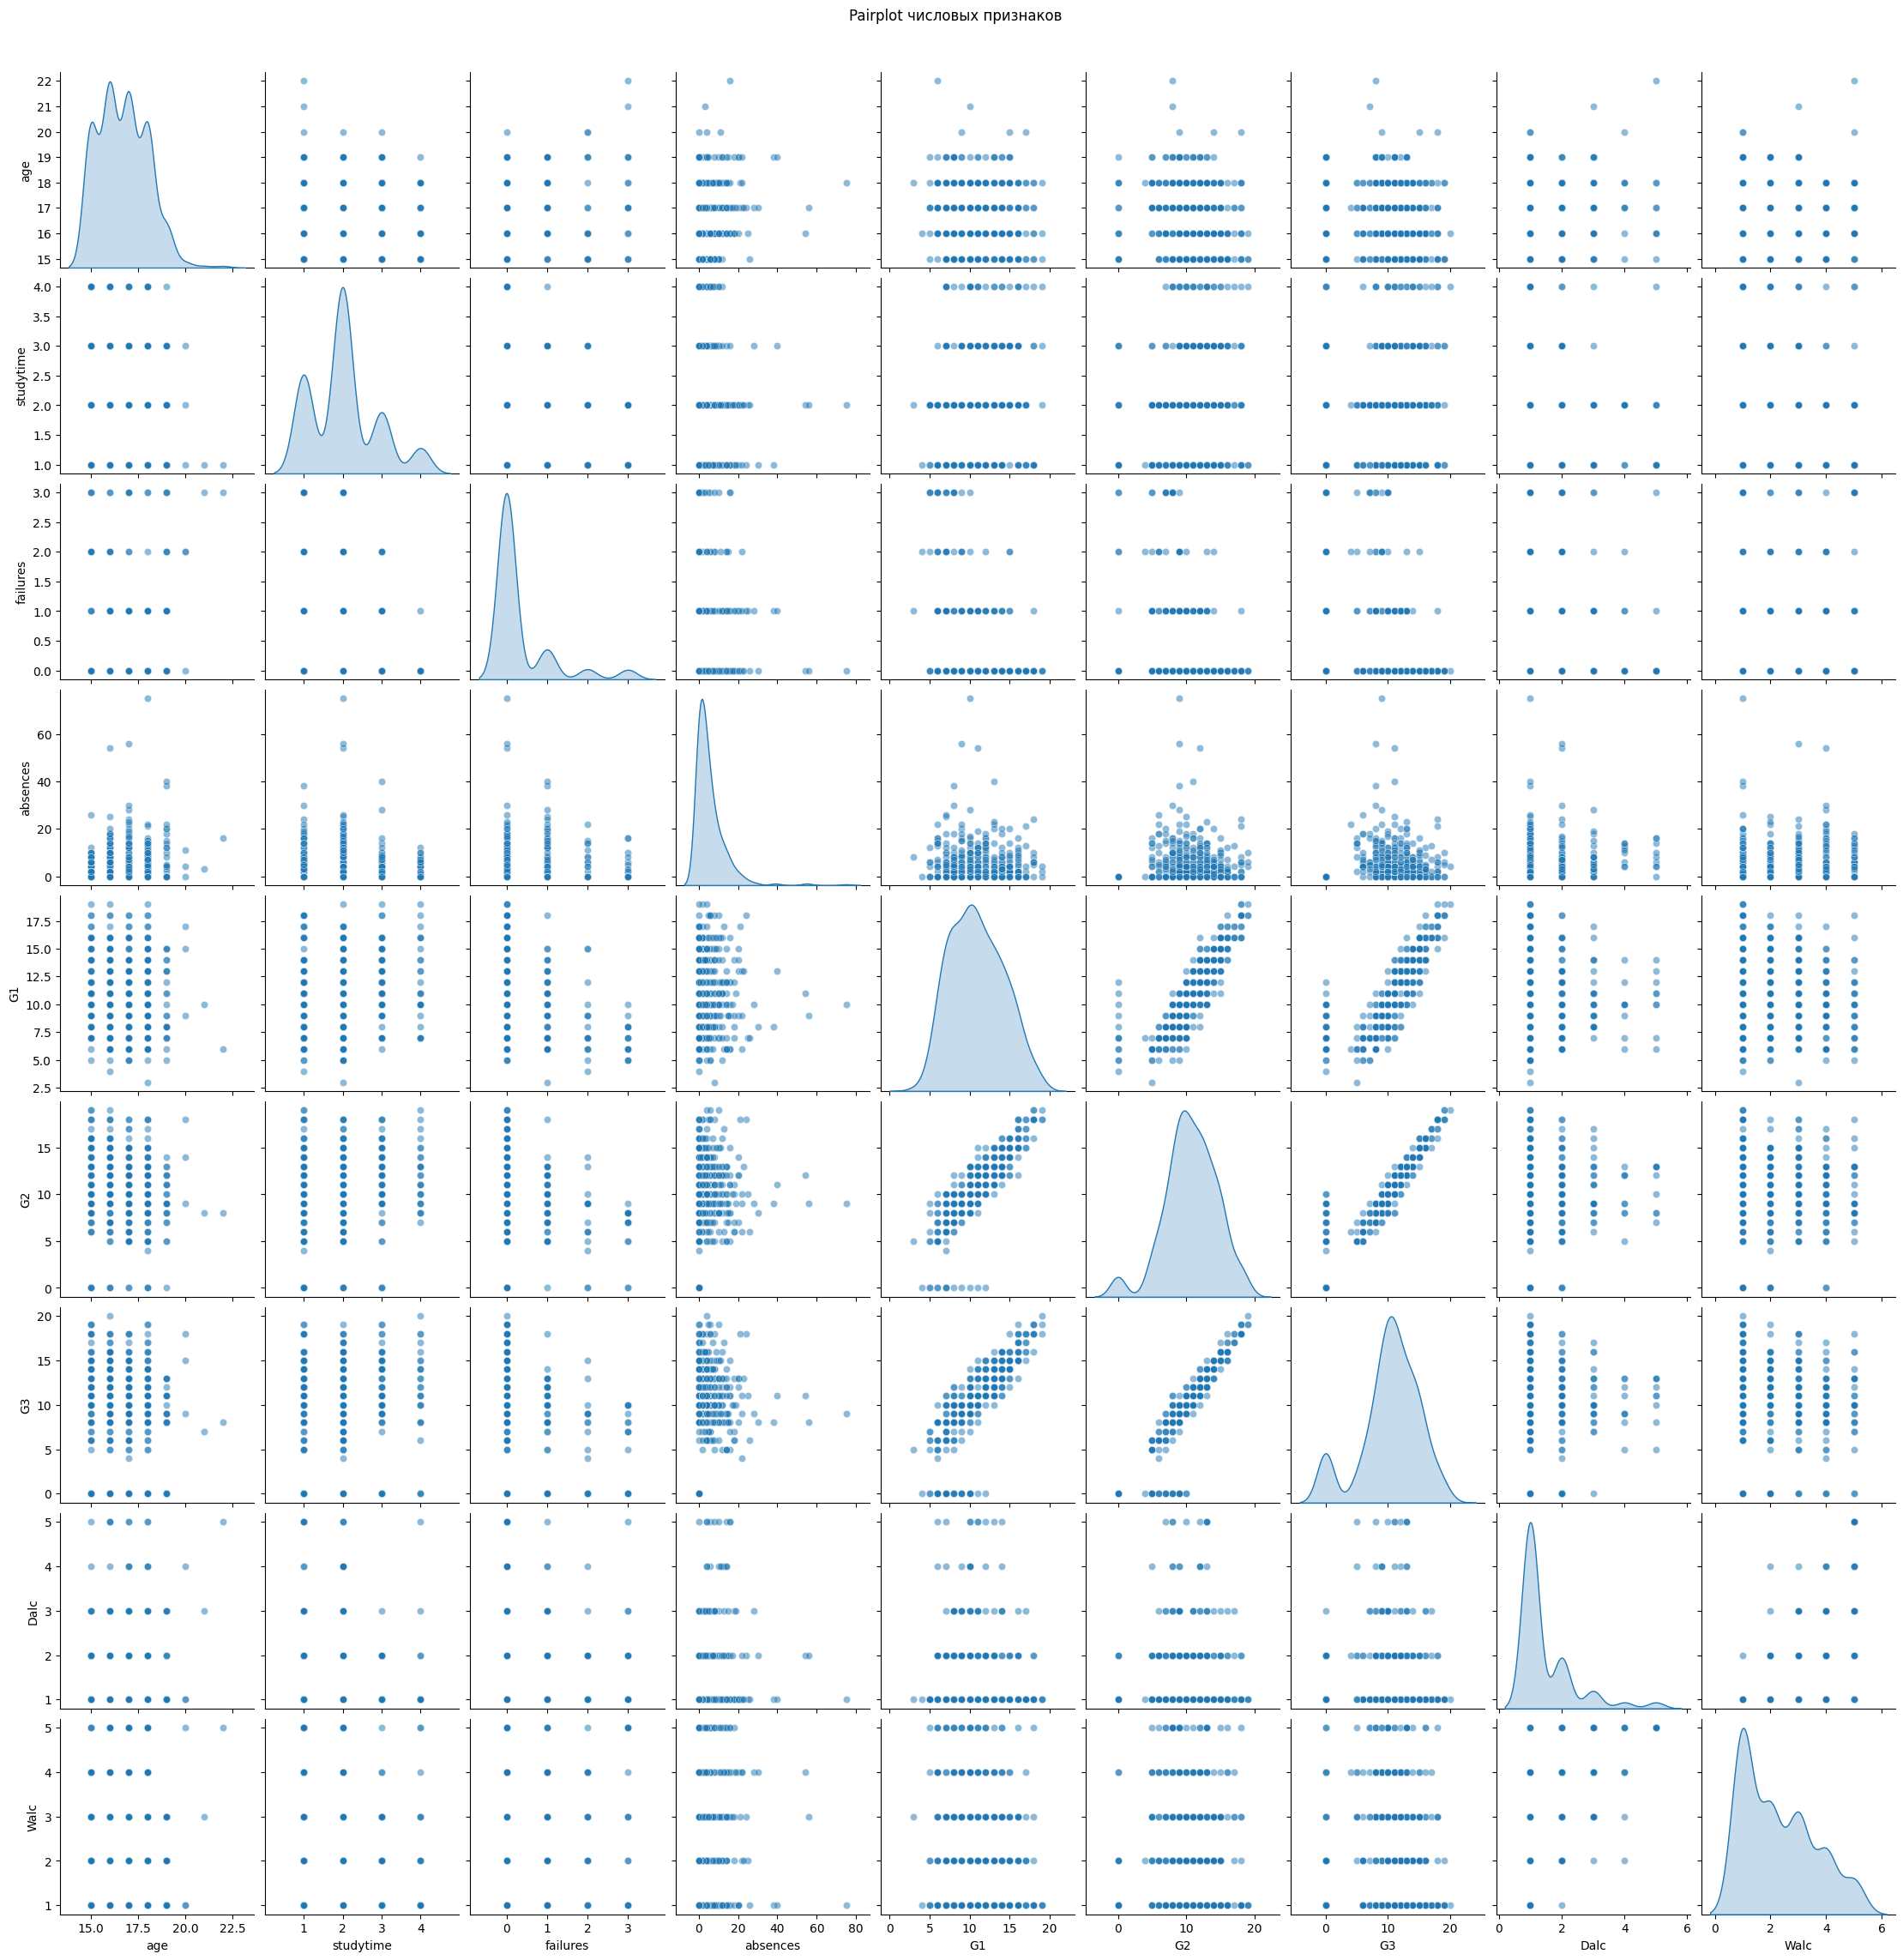

In [43]:
# Pairplot числовых признаков
numeric_cols = ['age', 'studytime', 'failures', 'absences', 'G1', 'G2', 'G3', 'Dalc', 'Walc']

sns.pairplot(df[numeric_cols], diag_kind='kde', plot_kws={'alpha':0.5})
plt.suptitle('Pairplot числовых признаков', y=1.02)
plt.show()

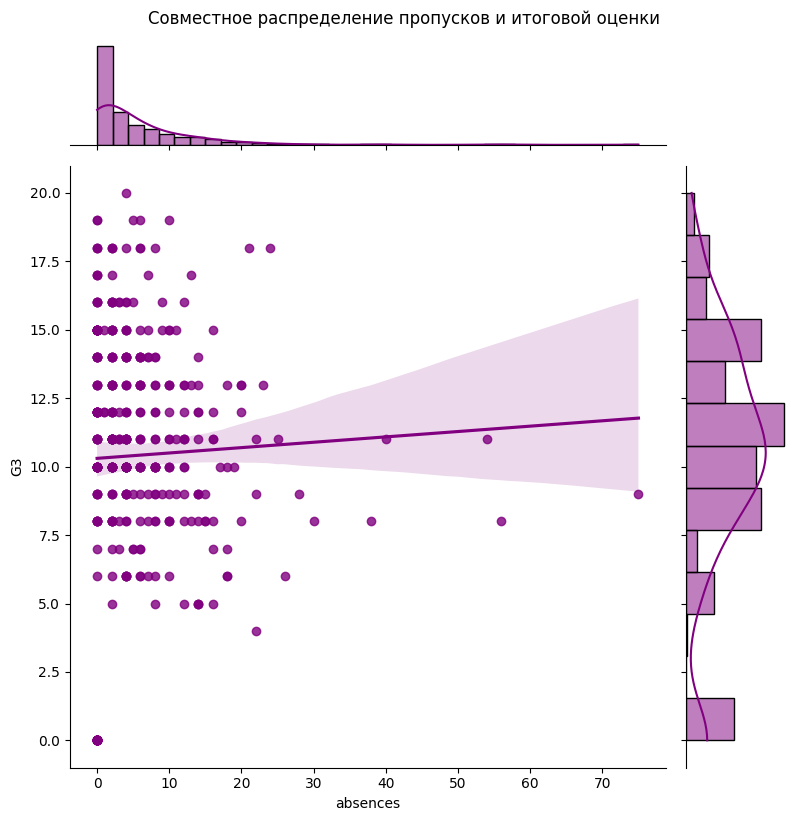

In [44]:
sns.jointplot(data=df, x='absences', y='G3', kind='reg', height=8, color='purple')
plt.suptitle('Совместное распределение пропусков и итоговой оценки', y=1.02)
plt.show()

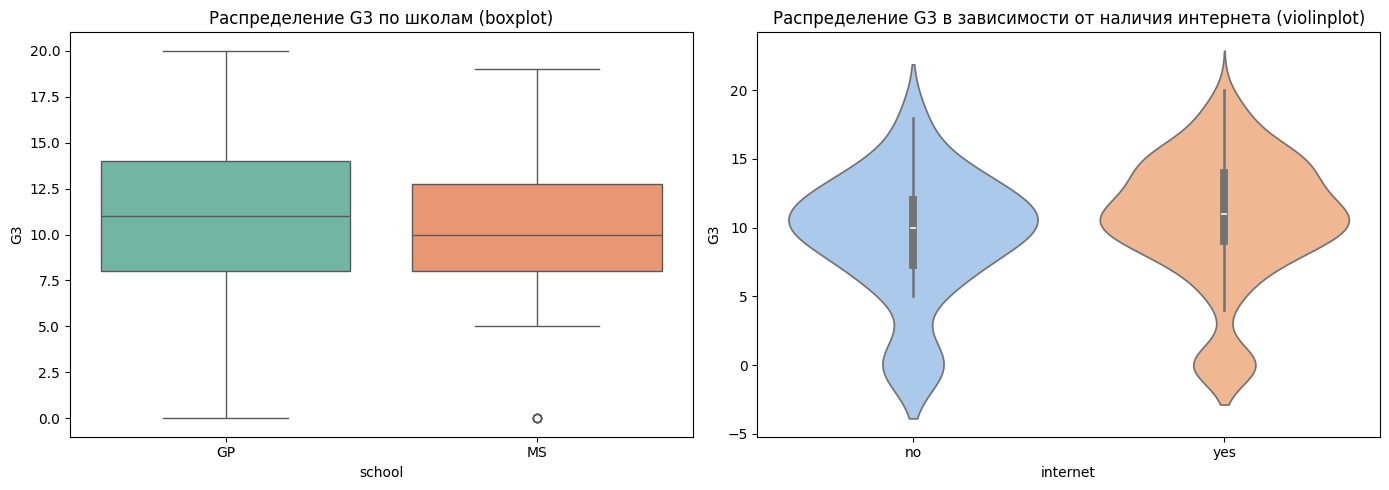

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.boxplot(data=df, x='school', y='G3', ax=axes[0], palette='Set2')
axes[0].set_title('Распределение G3 по школам (boxplot)')
sns.violinplot(data=df, x='internet', y='G3', ax=axes[1], palette='pastel')
axes[1].set_title('Распределение G3 в зависимости от наличия интернета (violinplot)')
plt.tight_layout()
plt.show()

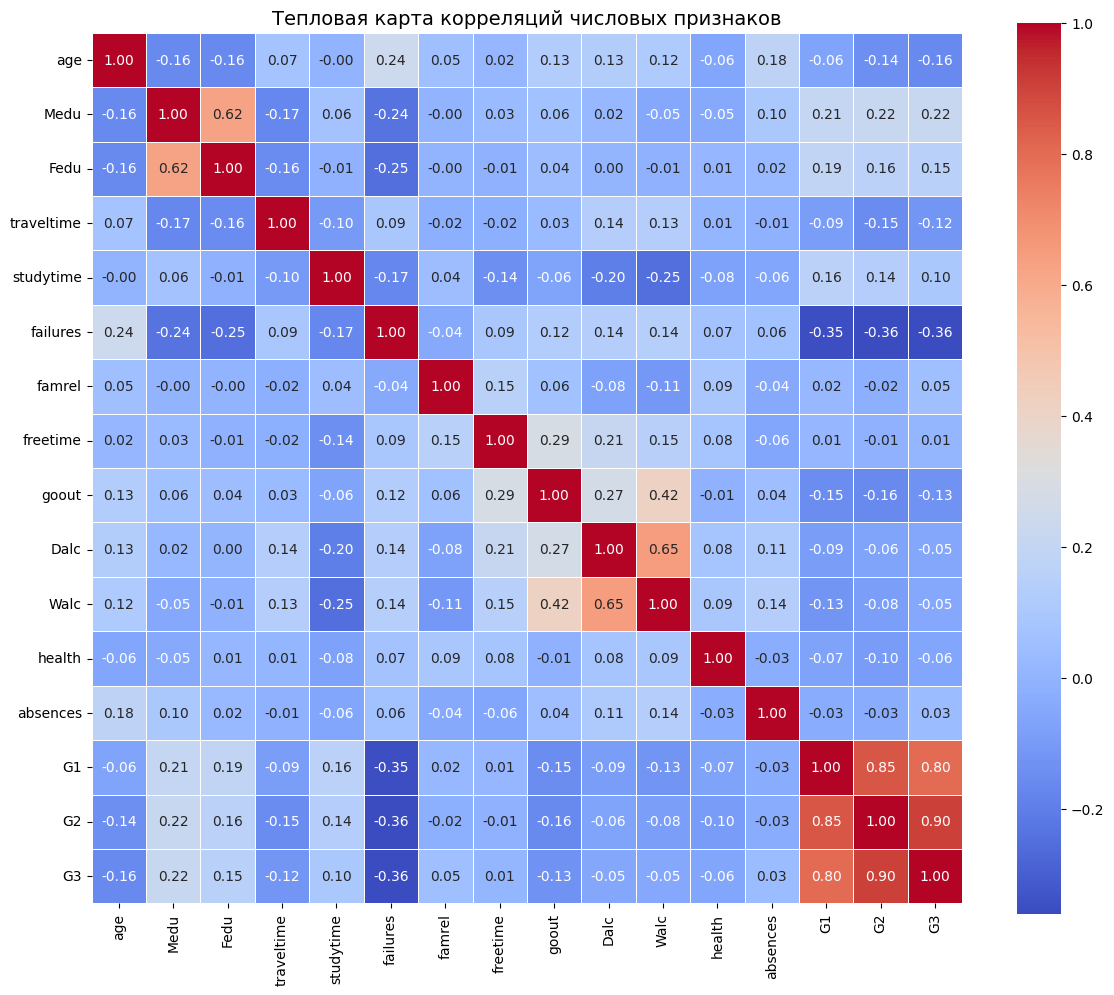

In [46]:
numeric_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(12, 10))
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True, linewidths=0.5)
plt.title('Тепловая карта корреляций числовых признаков', fontsize=14)
plt.tight_layout()
plt.show()

### 6. `scipy.stats`:  
   - Построить QQ-график (и гистограмму) для одного из числовых признаков с целью проверки на соответствие его распределения нормальному распределению.  

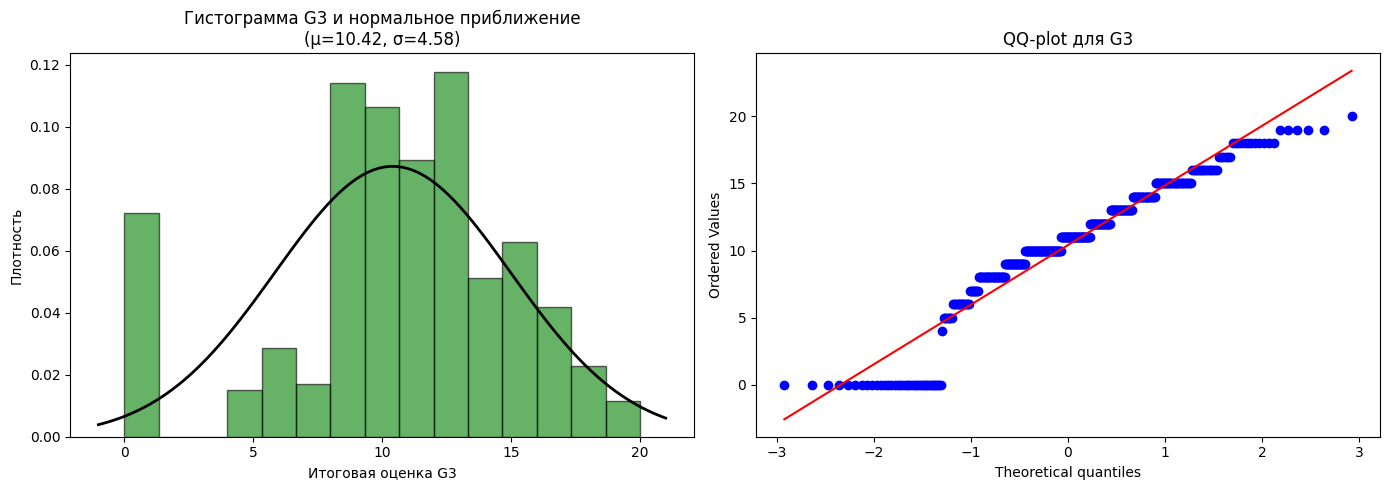

In [47]:
data_g3 = df['G3'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14,5))
# Гистограмма с кривой нормального распределения
axes[0].hist(data_g3, bins=15, density=True, alpha=0.6, color='g', edgecolor='black')
mu, std = stats.norm.fit(data_g3)
xmin, xmax = axes[0].get_xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, mu, std)
axes[0].plot(x, p, 'k', linewidth=2)
axes[0].set_title(f'Гистограмма G3 и нормальное приближение\n(μ={mu:.2f}, σ={std:.2f})')
axes[0].set_xlabel('Итоговая оценка G3')
axes[0].set_ylabel('Плотность')

stats.probplot(data_g3, dist="norm", plot=axes[1])
axes[1].set_title('QQ-plot для G3')
plt.tight_layout()
plt.show()

### 7. `plotly`:  
   - Построить несколько графиков разного вида.  
   - Построить несколько суб-графиков на одном графике.  
   - Построить интерактивный график.  
   
     > Использование `Dash` опционально.

In [48]:
fig1 = px.scatter(df, x='studytime', y='G3', color='Dalc',
                  size='absences', hover_data=['school', 'sex'],
                  title='Время учёбы vs Итоговая оценка (размер = пропуски, цвет = алкоголь в будни)',
                  labels={'studytime':'Время учёбы (1-4)', 'G3':'Оценка G3'})
fig1.show()


In [49]:
mean_g3_reason = df.groupby('reason')['G3'].mean().reset_index()
fig2 = px.bar(mean_g3_reason, x='reason', y='G3', color='reason',
              title='Средняя итоговая оценка в зависимости от причины выбора школы',
              labels={'G3':'Средняя G3'})
fig2.show()

In [50]:
fig3 = make_subplots(rows=2, cols=2,
                     subplot_titles=('Распределение пропусков', 'Алкоголь (будни vs выходные)',
                                     'Оценки по школам (boxplot)', 'Корреляция G1 и G3'))
# Histogram absences
fig3.add_trace(go.Histogram(x=df['absences'], nbinsx=30, name='Пропуски', marker_color='lightblue'), row=1, col=1)
# Boxplot Dalc и Walc (сгруппированные) – можно два боксплота на одном сабплоте
fig3.add_trace(go.Box(y=df['Dalc'], name='Dalc (будни)', marker_color='orange'), row=1, col=2)
fig3.add_trace(go.Box(y=df['Walc'], name='Walc (выходные)', marker_color='red'), row=1, col=2)
# Boxplot G3 по школам
for school in df['school'].unique():
    fig3.add_trace(go.Box(y=df[df['school']==school]['G3'], name=school), row=2, col=1)
# Scatter G1 vs G3
fig3.add_trace(go.Scatter(x=df['G1'], y=df['G3'], mode='markers', marker=dict(color='green', opacity=0.5), name='G1 vs G3'), row=2, col=2)

fig3.update_layout(height=800, width=1000, title_text="Интерактивные субграфики plotly")
fig3.show()

In [51]:
fig4 = px.scatter_3d(df, x='studytime', y='failures', z='G3', color='school',
                     size='absences', hover_name='age',
                     title='3D визуализация: время учёбы, количество неудач и итоговая оценка')
fig4.show()